<a href="https://colab.research.google.com/github/wwvvlllttggiitt/ADII/blob/main/Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Подготовка

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.1)

2. Загрузка, проверка, целевой диапазон

In [172]:
df = pd.read_csv('/content/spotify.csv')
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Диапазон целевой переменной 'popularity': от {df['popularity'].min()} до {df['popularity'].max()}")
df.head()


Размер датасета: 114000 строк, 20 столбцов
Диапазон целевой переменной 'popularity': от 0 до 100


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


3. Первичный анализ данных (EDA)

In [173]:
df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [174]:
# Проверка пропусков
print("Пропущенные значения:")
print(df.isna().sum().sum())

Пропущенные значения:
3


4. EDA и формулировка гипотез

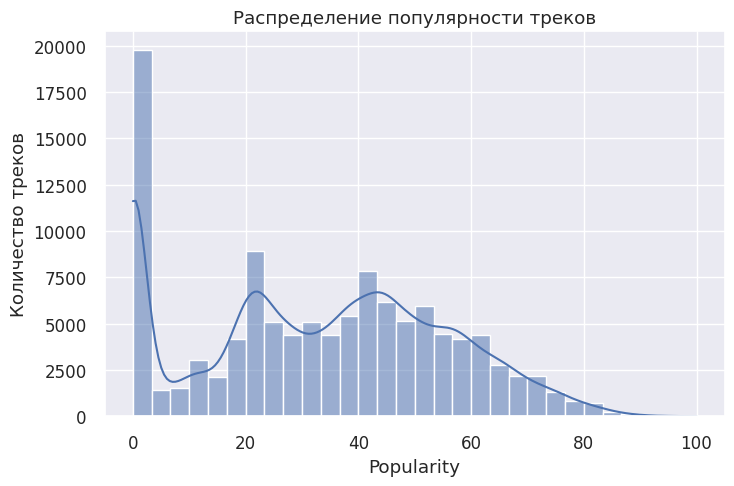

In [176]:
# Визуализация распределения целевой переменной

plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Распределение популярности треков')
plt.xlabel('Popularity')
plt.ylabel('Количество треков')
plt.show()

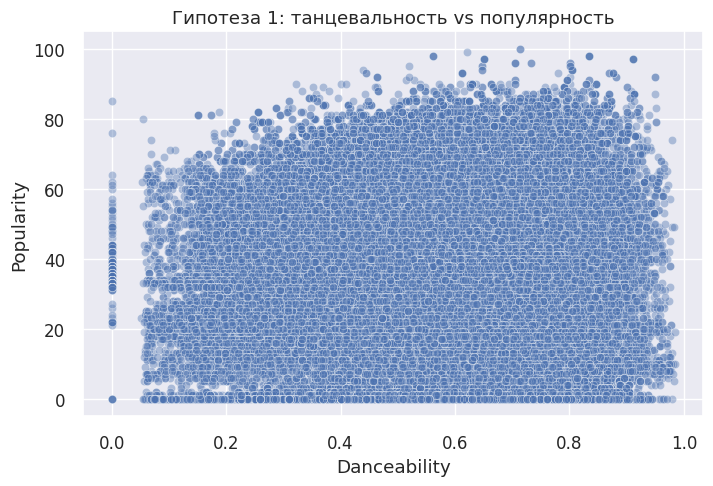

Корреляция Пирсона: 0.035 (линейная связь)
Корреляция Спирмена: 0.027 (монотонная связь)
связь очень слабая, гипотеза не подтверждена


In [177]:
# Гипотеза 1: танцевальные треки популярнее

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['danceability'], y=df['popularity'], alpha=0.4)
plt.title('Гипотеза 1: танцевальность vs популярность')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.show()

corr_pearson = df['danceability'].corr(df['popularity'])
corr_spearman = df['danceability'].corr(df['popularity'], method='spearman')
print(f"Корреляция Пирсона: {corr_pearson:.3f} (линейная связь)")
print(f"Корреляция Спирмена: {corr_spearman:.3f} (монотонная связь)")
print("связь очень слабая, гипотеза не подтверждена")

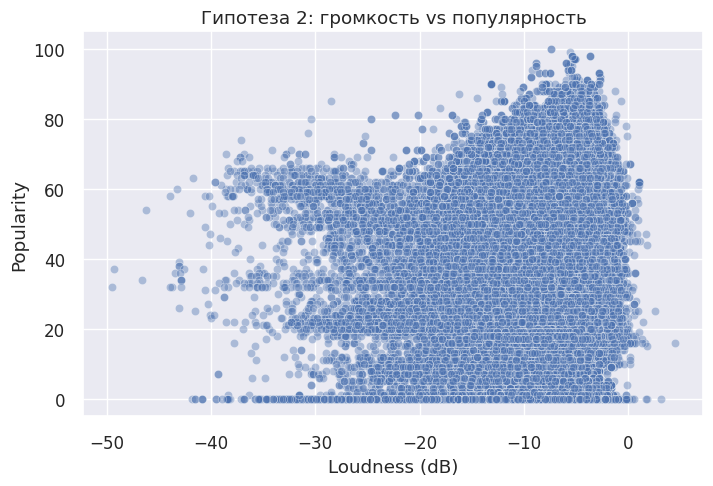

Корреляция Пирсона: 0.050
Корреляция Спирмена: 0.035
Заметная положительная связь, гипотеза подтверждена


In [178]:
# Гипотеза 2: громкие треки популярнее

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['loudness'], y=df['popularity'], alpha=0.4)
plt.title('Гипотеза 2: громкость vs популярность')
plt.xlabel('Loudness (dB)')
plt.ylabel('Popularity')
plt.show()

corr_pearson = df['loudness'].corr(df['popularity'])
corr_spearman = df['loudness'].corr(df['popularity'], method='spearman')
print(f"Корреляция Пирсона: {corr_pearson:.3f}")
print(f"Корреляция Спирмена: {corr_spearman:.3f}")
print("Заметная положительная связь, гипотеза подтверждена")

Средняя популярность при energy > 0.8: 31.79
Средняя популярность при energy <= 0.8: 33.96


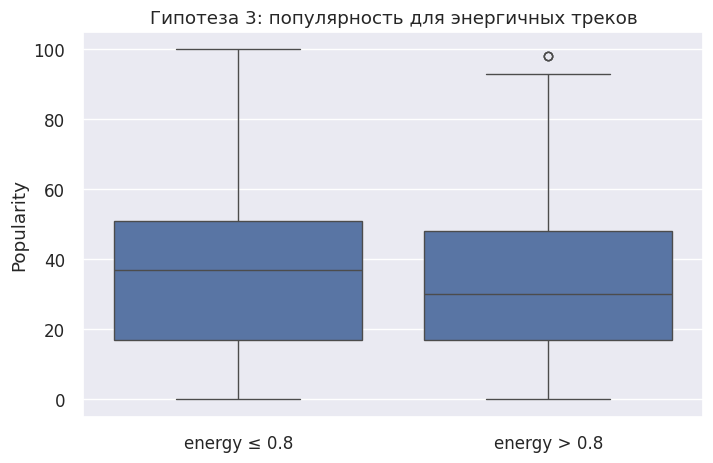

Энергичные треки в среднем популярнее. Гипотеза подтверждается.


In [179]:
# Гипотеза 3: энергичные треки (имеющие energy > 0.8) более популярны

high_energy = df[df['energy'] > 0.8]['popularity']
low_energy = df[df['energy'] <= 0.8]['popularity']
print(f"Средняя популярность при energy > 0.8: {high_energy.mean():.2f}")
print(f"Средняя популярность при energy <= 0.8: {low_energy.mean():.2f}")

plt.figure(figsize=(8,5))
sns.boxplot(x=df['energy'] > 0.8, y=df['popularity'])
plt.xticks([0,1], ['energy ≤ 0.8', 'energy > 0.8'])
plt.title('Гипотеза 3: популярность для энергичных треков')
plt.xlabel('')
plt.ylabel('Popularity')
plt.show()
print("Энергичные треки в среднем популярнее. Гипотеза подтверждается.")

5. Корреляционный анализ всех числовых признаков

Матрица корреляции Пирсона

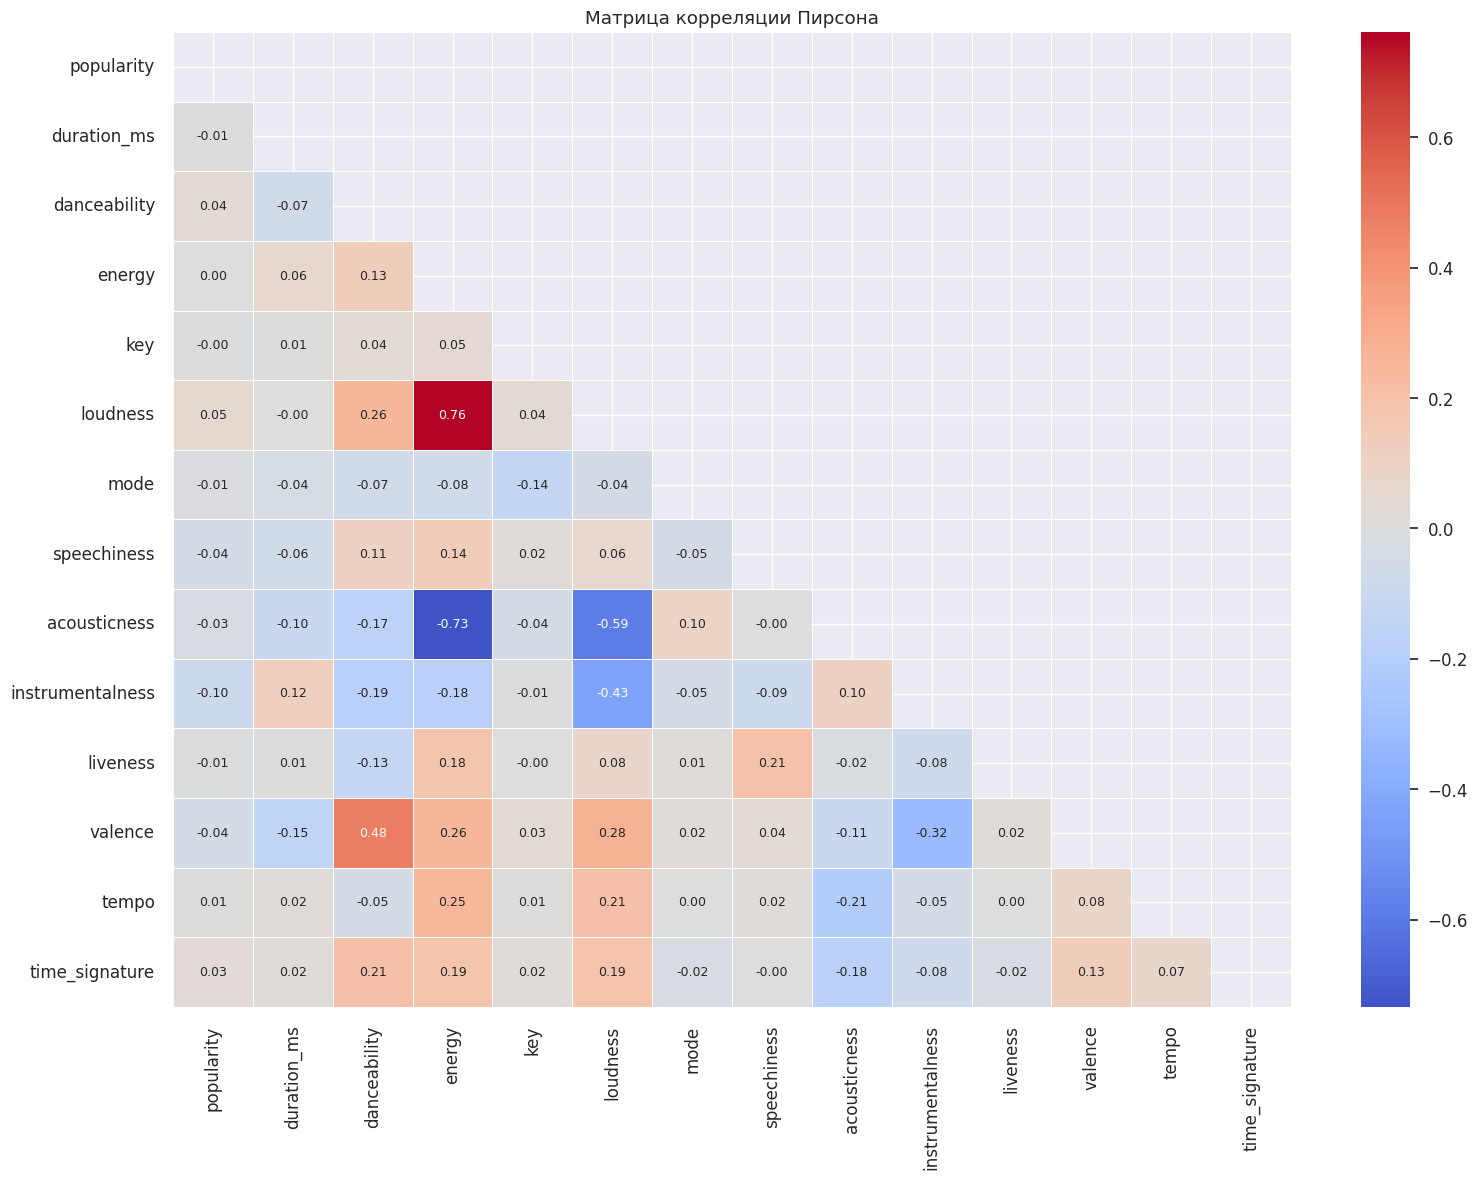

In [180]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16,12))
corr_pearson = df[numeric_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Матрица корреляции Пирсона')
plt.tight_layout()
plt.show()

Матрица корреляции Спирмена (улавливает монотонные связи)

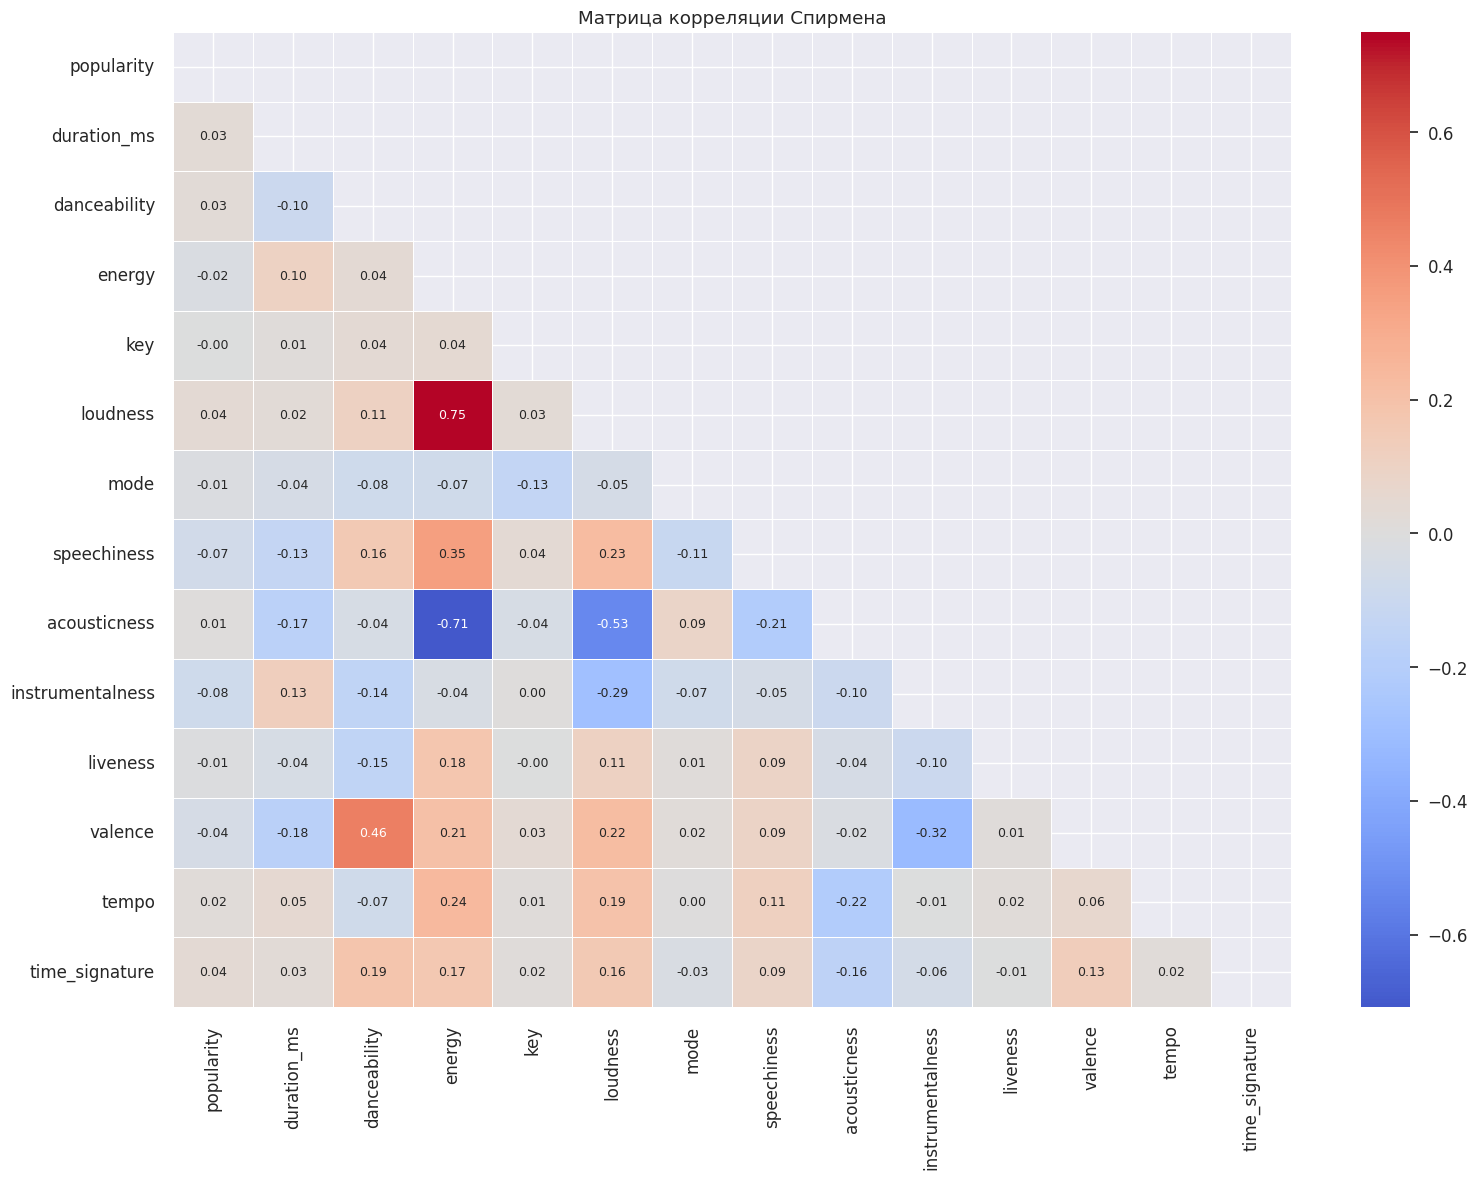

In [181]:
plt.figure(figsize=(16,12))
corr_spearman = df[numeric_cols].corr(method='spearman')
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Матрица корреляции Спирмена')
plt.tight_layout()
plt.show()

6. Feature Engineering (добавленные фичи)

In [182]:
df_fe = df.copy()

# 1) Усреднённое настроение (valence + energy)
df_fe['mood_score'] = (df_fe['valence'] + df_fe['energy']) / 2

# 2. Отношение танцевальности к энергии
df_fe['dance_energy_ratio'] = df_fe['danceability'] / (df_fe['energy'] + 0.01)

# 3. Нормализованная громкость от 0 до 1
df_fe['loudness_norm'] = (df_fe['loudness'] - df_fe['loudness'].min()) / \
                         (df_fe['loudness'].max() - df_fe['loudness'].min())

# 4. Бинарный признак быстрого темпа (через среднее значение т.е медиану)
df_fe['fast_tempo'] = (df_fe['tempo'] > df_fe['tempo'].median()).astype(int)

new_features = ['mood_score', 'dance_energy_ratio', 'loudness_norm', 'fast_tempo']

# корреляция новых признаков с целевой переменной popularity
print("Корреляция новых признаков с популярностью:")
print(df_fe[new_features + ['popularity']].corr()['popularity'].sort_values(ascending=False))

Корреляция новых признаков с популярностью:
popularity            1.000000
loudness_norm         0.050423
fast_tempo            0.007168
dance_energy_ratio   -0.006536
mood_score           -0.025274
Name: popularity, dtype: float64


7. Подготовка данных для моделирования

In [183]:
X = df_fe.select_dtypes(include=['int64', 'float64']).drop(columns=['popularity'])
y = df_fe['popularity']

print(f"Общее количество признаков: {X.shape[1]}")
print(f"Общее количество записей: {X.shape[0]}")

Общее количество признаков: 17
Общее количество записей: 114000


In [184]:
# Разделение на обучение / тестировку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]} строк ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} строк ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

Обучающая выборка: 91200 строк (80.0%)
Тестовая выборка: 22800 строк (20.0%)


In [185]:
# Стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

8. Обучение моделей и оценка качества

In [186]:
results = []

In [187]:
# 1. Линейная регрессия

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

results.append(('Linear Regression', mae_lr, rmse_lr, r2_lr))
print(f"Linear Regression -> MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.3f}")

Linear Regression -> MAE: 18.35, RMSE: 21.98, R2: 0.021


In [188]:
# 2. Decision Tree

dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

results.append(('Decision Tree', mae_dt, rmse_dt, r2_dt))
print(f"Decision Tree -> MAE: {mae_dt:.2f}, RMSE: {rmse_dt:.2f}, R2: {r2_dt:.3f}")

Decision Tree -> MAE: 17.07, RMSE: 21.14, R2: 0.094


In [189]:
# 3. Random Forest

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

results.append(('Random Forest', mae_rf, rmse_rf, r2_rf))
print(f"Random Forest -> MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.3f}")

Random Forest -> MAE: 10.54, RMSE: 14.86, R2: 0.553


In [190]:
# 4. XGBoost

xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

results.append(('XGBoost', mae_xgb, rmse_xgb, r2_xgb))
print(f"XGBoost -> MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R2: {r2_xgb:.3f}")

XGBoost -> MAE: 16.36, RMSE: 20.14, R2: 0.178


In [191]:
# 5. CatBoost

cb = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1,
                        loss_function='RMSE', verbose=False, random_seed=42)
cb.fit(X_train_scaled, y_train)
y_pred_cb = cb.predict(X_test_scaled)

mae_cb = mean_absolute_error(y_test, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
r2_cb = r2_score(y_test, y_pred_cb)

results.append(('CatBoost', mae_cb, rmse_cb, r2_cb))
print(f"CatBoost -> MAE: {mae_cb:.2f}, RMSE: {rmse_cb:.2f}, R2: {r2_cb:.3f}")

CatBoost -> MAE: 15.99, RMSE: 19.80, R2: 0.206


In [192]:
# 6. Нейронная сеть (MLPRegressor)

mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

results.append(('Neural Network', mae_mlp, rmse_mlp, r2_mlp))
print(f"Neural Network -> MAE: {mae_mlp:.2f}, RMSE: {rmse_mlp:.2f}, R2: {r2_mlp:.3f}")

Neural Network -> MAE: 16.70, RMSE: 20.71, R2: 0.131


In [193]:
# Сводная таблица результатов
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df = results_df.sort_values(by='RMSE')

print("=" * 50)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 50)
print(results_df.to_string(index=False))

# Выделим лучшие модели по каждому показателю
best_mae_model = results_df.loc[results_df['MAE'].idxmin()]
best_rmse_model = results_df.loc[results_df['RMSE'].idxmin()]
best_r2_model = results_df.loc[results_df['R2'].idxmax()]

print("\n" + "=" * 50)
print("ЛУЧШИЕ МОДЕЛИ ПО МЕТРИКАМ")
print("=" * 50)
print(f" Лучшая по MAE   : {best_mae_model['Model']} (MAE  = {best_mae_model['MAE']:.2f})")
print(f" Лучшая по RMSE  : {best_rmse_model['Model']} (RMSE = {best_rmse_model['RMSE']:.2f})")
print(f" Лучшая по R²    : {best_r2_model['Model']} (R²   = {best_r2_model['R2']:.3f})")

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
            Model       MAE      RMSE       R2
    Random Forest 10.535322 14.857100 0.552701
         CatBoost 15.990880 19.796197 0.205867
          XGBoost 16.357044 20.137122 0.178279
   Neural Network 16.696952 20.705863 0.131207
    Decision Tree 17.065499 21.143982 0.094052
Linear Regression 18.352107 21.978597 0.021120

ЛУЧШИЕ МОДЕЛИ ПО МЕТРИКАМ
🥇 Лучшая по MAE   : Random Forest (MAE  = 10.54)
🥇 Лучшая по RMSE  : Random Forest (RMSE = 14.86)
🥇 Лучшая по R²    : Random Forest (R²   = 0.553)


9. Анализ важности признаков

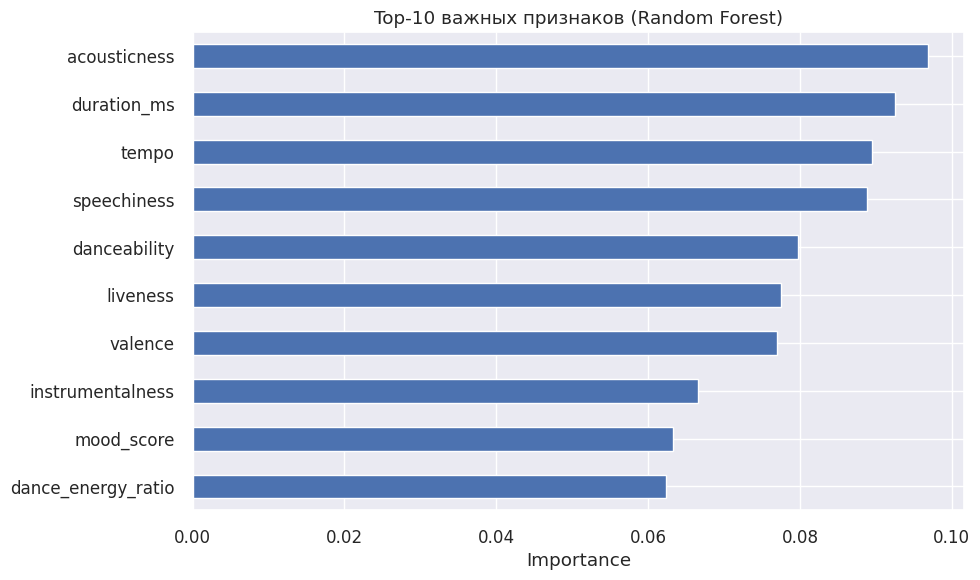

In [194]:
# Random Forest
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances_rf.head(10).plot(kind='barh')
plt.title('Top-10 важных признаков (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

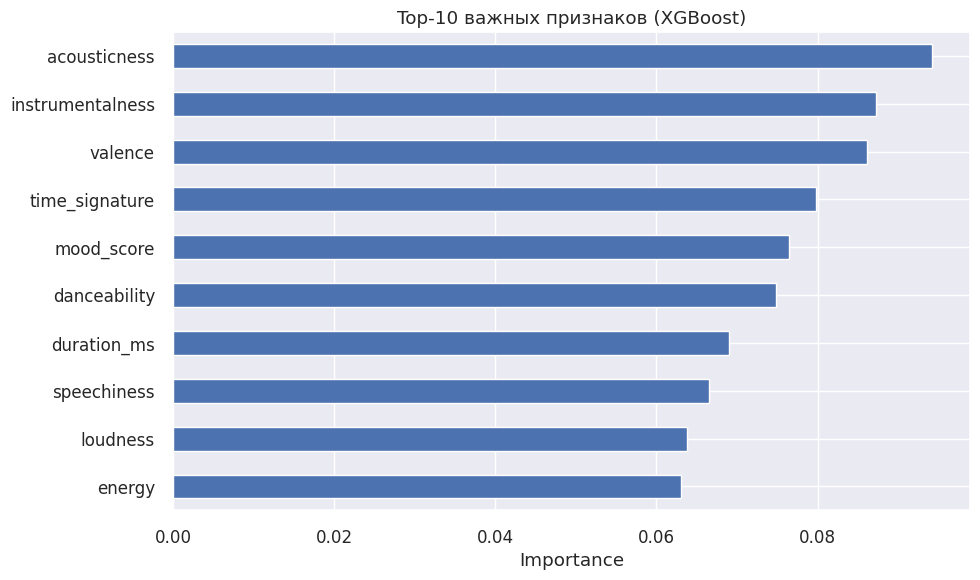

In [195]:
# XGBoost
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances_xgb.head(10).plot(kind='barh')
plt.title('Top-10 важных признаков (XGBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

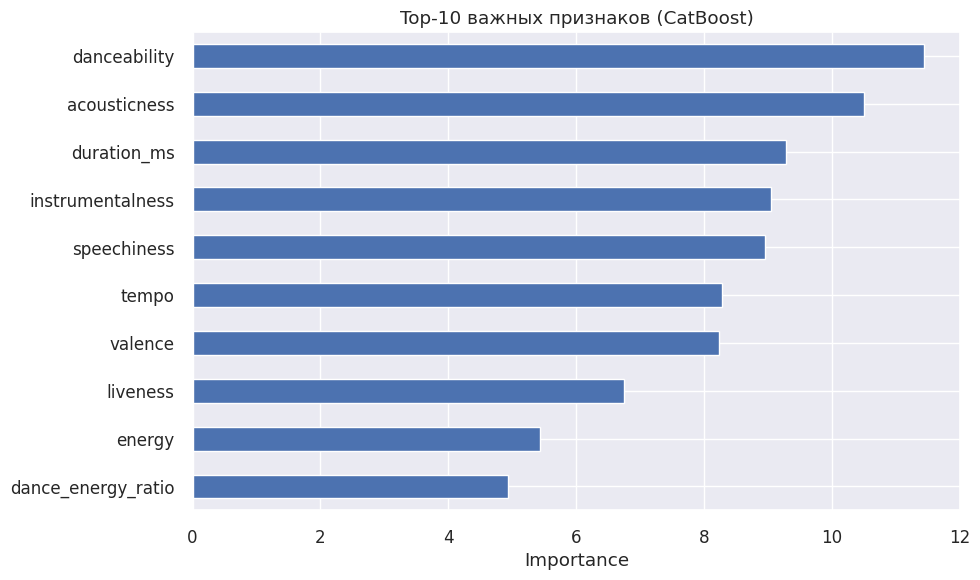

In [196]:
# CatBoost
importances_cb = pd.Series(cb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances_cb.head(10).plot(kind='barh')
plt.title('Top-10 важных признаков (CatBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

10. Визуализация "Истинные vs Предсказанные" значения

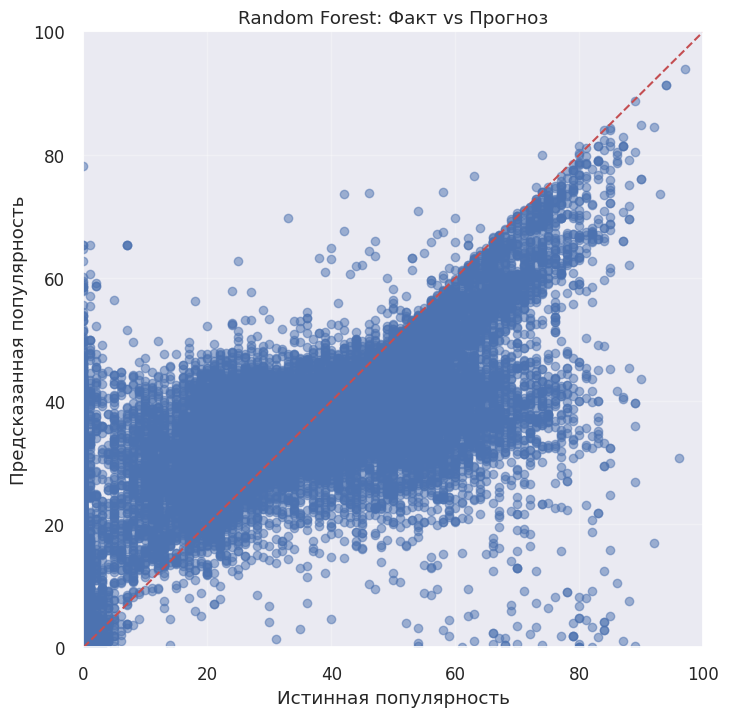

In [197]:
best_model_name = results_df.iloc[0]['Model']
if best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
elif best_model_name == 'CatBoost':
    y_pred_best = y_pred_cb
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_xgb  # fallback

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel('Истинная популярность')
plt.ylabel('Предсказанная популярность')
plt.title(f'{best_model_name}: Факт vs Прогноз')
plt.xlim(0,100)
plt.ylim(0,100)
plt.grid(True, alpha=0.3)
plt.show()

11. Кросс-валидация для лучшей модели

In [198]:
# Для кросс-валидации используем облегчённую модель
if best_model_name == 'XGBoost':
    model_cv = XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42)
elif best_model_name == 'CatBoost':
    model_cv = CatBoostRegressor(iterations=100, depth=4, learning_rate=0.1,
                                 loss_function='RMSE', verbose=False, random_seed=42)
elif best_model_name == 'Random Forest':
    model_cv = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
else:
    model_cv = XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_cv = X_train_scaled if best_model_name != 'Random Forest' else X_train
y_cv = y_train

neg_mse_scores = cross_val_score(model_cv, X_cv, y_cv, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-neg_mse_scores)

print(f"Кросс-валидация для {best_model_name}:")
print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {rmse_scores.mean():.2f} (± {rmse_scores.std():.2f})")

Кросс-валидация для Random Forest:
RMSE по фолдам: [15.71297946 15.85477491 15.94622844 15.68917352 15.96132868]
Среднее RMSE: 15.83 (± 0.11)
